In [2]:
   print("Hello!")

Hello!


In [3]:
from pathlib import Path
from dotenv import load_dotenv
import os
import requests

env_path = Path.cwd().parent / ".env"
print("Looking here:", env_path)
print("Found it:", env_path.exists())

load_dotenv(dotenv_path=env_path)
api_key = os.getenv("CFBD_API_KEY")
print("Key found:", api_key is not None)

headers = {"Authorization": f"Bearer {api_key}"}
response = requests.get(
    "https://api.collegefootballdata.com/games",
    headers=headers,
    params={"year": 2023, "week": 1, "seasonType": "regular"}
)

print("Status code:", response.status_code)
print("Number of games returned:", len(response.json()))

Looking here: /Users/micahshelley/Desktop/cfp-scheduling-project/.env
Found it: True
Key found: True
Status code: 200
Number of games returned: 333


In [4]:
import time

years = range(2014, 2026)  # this means 2014 up through 2025
team_win_pct = {}  # this will store: (year, team name) -> win percentage

for year in years:
    response = requests.get(
        "https://api.collegefootballdata.com/records",
        headers=headers,
        params={"year": year}
    )
    if response.status_code != 200:
        print(f"Problem fetching {year}: {response.status_code}")
        continue

    records = response.json()
    for team_record in records:
        team = team_record["team"]
        total = team_record["total"]
        games_played = total["games"]
        wins = total["wins"]
        win_pct = wins / games_played if games_played > 0 else None
        team_win_pct[(year, team)] = win_pct

    time.sleep(0.2)  # a small pause so we're not hammering their server

print("Total team-seasons collected:", len(team_win_pct))
print(list(team_win_pct.items())[:5])  # peek at 5 examples

Total team-seasons collected: 8120
[((2014, 'Auburn'), 0.6153846153846154), ((2014, 'Birmingham-Southern'), 0.0), ((2014, 'UAB'), 0.5), ((2014, 'South Alabama'), 0.46153846153846156), ((2014, 'Amherst'), None)]


In [5]:
POWER_CONFERENCES = {"ACC", "Big Ten", "Big 12", "SEC"}

rows = []

for year in years:
    response = requests.get(
        "https://api.collegefootballdata.com/games",
        headers=headers,
        params={"year": year, "seasonType": "regular"}
    )
    if response.status_code != 200:
        print(f"Problem fetching games for {year}: {response.status_code}")
        continue

    games = response.json()

    for game in games:
        if game.get("conferenceGame"):
            continue  # skip conference games, we only want non-conference ones

        home_team = game.get("homeTeam")
        away_team = game.get("awayTeam")
        home_conf = game.get("homeConference")
        away_conf = game.get("awayConference")

        if home_conf in POWER_CONFERENCES:
            rows.append({
                "season": year,
                "team": home_team,
                "team_conference": home_conf,
                "opponent": away_team,
                "opponent_conference": away_conf,
                "opponent_win_pct": team_win_pct.get((year, away_team))
            })

        if away_conf in POWER_CONFERENCES:
            rows.append({
                "season": year,
                "team": away_team,
                "team_conference": away_conf,
                "opponent": home_team,
                "opponent_conference": home_conf,
                "opponent_win_pct": team_win_pct.get((year, home_team))
            })

    time.sleep(0.2)

print("Total non-conference matchups collected:", len(rows))
print(rows[:3])

Total non-conference matchups collected: 2179
[{'season': 2014, 'team': 'Wake Forest', 'team_conference': 'ACC', 'opponent': 'UL Monroe', 'opponent_conference': 'Sun Belt', 'opponent_win_pct': 0.3333333333333333}, {'season': 2014, 'team': 'Minnesota', 'team_conference': 'Big Ten', 'opponent': 'Eastern Illinois', 'opponent_conference': 'OVC', 'opponent_win_pct': 0.4166666666666667}, {'season': 2014, 'team': 'Ole Miss', 'team_conference': 'SEC', 'opponent': 'Boise State', 'opponent_conference': 'Mountain West', 'opponent_win_pct': 0.8571428571428571}]


In [6]:
import pandas as pd

df = pd.DataFrame(rows)

print("Shape (rows, columns):", df.shape)
print(df.head())
print("Games with a missing opponent win percentage:", df["opponent_win_pct"].isna().sum())

df.to_csv("../data/non_conference_games.csv", index=False)
print("Saved!")

Shape (rows, columns): (2179, 6)
   season         team team_conference          opponent opponent_conference  \
0    2014  Wake Forest             ACC         UL Monroe            Sun Belt   
1    2014    Minnesota         Big Ten  Eastern Illinois                 OVC   
2    2014     Ole Miss             SEC       Boise State       Mountain West   
3    2014      Rutgers         Big Ten  Washington State              Pac-12   
4    2014   Vanderbilt             SEC            Temple   American Athletic   

   opponent_win_pct  
0          0.333333  
1          0.416667  
2          0.857143  
3          0.250000  
4          0.500000  
Games with a missing opponent win percentage: 0
Saved!


In [7]:
df["era"] = df["season"].apply(
    lambda year: "Four-Team Era (2014-2023)" if year <= 2023 else "Twelve-Team Era (2024-2025)"
)

print("Average opponent win % by season:")
print(df.groupby("season")["opponent_win_pct"].mean())

print("\nAverage opponent win % by era:")
print(df.groupby("era")["opponent_win_pct"].mean())

Average opponent win % by season:
season
2014    0.515225
2015    0.521933
2016    0.501345
2017    0.504009
2018    0.503317
2019    0.496262
2020    0.478926
2021    0.474971
2022    0.484543
2023    0.504854
2024    0.507384
2025    0.507759
Name: opponent_win_pct, dtype: float64

Average opponent win % by era:
era
Four-Team Era (2014-2023)      0.500818
Twelve-Team Era (2024-2025)    0.507575
Name: opponent_win_pct, dtype: float64


In [8]:
from scipy import stats

four_team = df[df["era"] == "Four-Team Era (2014-2023)"]["opponent_win_pct"]
twelve_team = df[df["era"] == "Twelve-Team Era (2024-2025)"]["opponent_win_pct"]

t_stat, p_value = stats.ttest_ind(four_team, twelve_team, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -0.6010613462673619
p-value: 0.54797986005677


Matplotlib is building the font cache; this may take a moment.


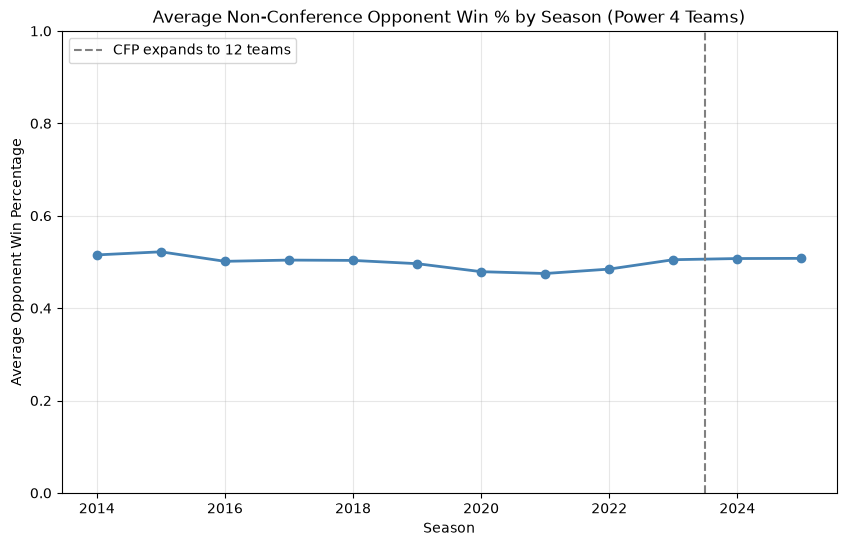

In [10]:
import matplotlib.pyplot as plt

season_avg = df.groupby("season")["opponent_win_pct"].mean()

plt.figure(figsize=(10, 6))
plt.plot(season_avg.index, season_avg.values, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=2023.5, color="gray", linestyle="--", label="CFP expands to 12 teams")
plt.title("Average Non-Conference Opponent Win % by Season (Power 4 Teams)")
plt.xlabel("Season")
plt.ylabel("Average Opponent Win Percentage")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../docs/opponent_win_pct_chart.png", dpi=150, bbox_inches="tight")
plt.show()

   ## Conclusion: No, the data does not support the idea that non-conference opponents got easier after the Playoff expanded to 12 teams. If anything, the average opponent win percentage went up very slightly (50.1% → 50.8%) in the new era, not down — but that tiny difference isn't statistically significant, so the honest conclusion is: scheduling behavior hasn't meaningfully changed, at least not in this specific measure, at least not yet with only two seasons of data.